# Logistic Regression from Scratch

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

Until now, every model you have trained predicted a number. In this notebook you build your first <b>classification</b> model, where the target is a category instead: here, a binary 0/1 label. The algorithm is called logistic regression, and despite the name it does classification, not regression.

Why not just reuse linear regression? Because its output is unbounded: on a 0/1 target it happily predicts values like 1.4 or -0.5, which cannot be read as probabilities. Logistic regression fixes this with one addition, the <b>sigmoid function</b>, which squashes any real number into a probability between 0 and 1. A threshold (usually 0.5) then turns that probability into a class label.

The loss function changes from MSE to <b>log loss</b> (binary cross-entropy), which penalises confident wrong predictions more harshly. Surprisingly, the gradient descent update rule that follows is almost identical to what you implemented for linear regression.

Below, you will implement those additions from scratch, visualise the decision boundary your model draws, and verify your implementation against sklearn.

</div>

---
## Step 1: Generate and Explore the Dataset

We will use a small synthetic dataset: 300 samples, 2 features, binary labels. Two features let us plot the model's decision boundary on a flat 2D surface — impossible with real multi-feature datasets.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=RANDOM_SEED,
)

print(f'X shape: {X.shape}    y shape: {y.shape}')
print(f'Positive rate: {y.mean():.2f}')

X shape: (300, 2)    y shape: (300,)
Positive rate: 0.50


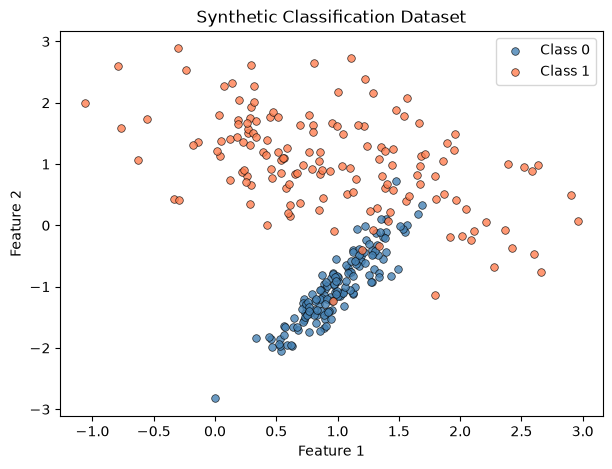

In [36]:
# Visualise the two classes
plt.figure(figsize=(7, 5))
for label, color in [(0, 'steelblue'), (1, 'coral')]:
    mask = y == label
    plt.scatter(X[mask, 0], X[mask, 1], c=color, s=30, edgecolors='black',
                linewidths=0.5, alpha=0.8, label=f'Class {label}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Classification Dataset')
plt.legend()
plt.show()

---
## Step 2: From Linear Regression to Logistic Regression

Before building anything new, let's confirm the problem. The code below ignores the fact that `y` holds class labels and fits plain linear regression to the 0/1 values, then checks what the "predictions" look like.

In [37]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_preds = lin_reg.predict(X)

print(f'Actual target values:        {np.unique(y)}')
print(f'Linear regression predicts:  {lin_preds.min():.2f} to {lin_preds.max():.2f}')
print(f'Predictions below 0: {(lin_preds < 0).sum()} samples')
print(f'Predictions above 1: {(lin_preds > 1).sum()} samples')

Actual target values:        [0 1]
Linear regression predicts:  -0.53 to 1.44
Predictions below 0: 36 samples
Predictions above 1: 40 samples


> **Note:** The target only ever takes the values 0 and 1, yet the model predicts anywhere from about -0.5 to 1.4, and roughly a quarter of the predictions fall outside [0, 1] entirely. A value of 1.4 cannot be a probability, and there is no principled way to interpret it. This is the problem the sigmoid solves.

### What Changes and What Stays the Same

| Aspect | Linear Regression | Logistic Regression |
|--------|------------------|---------------------|
| Task | Continuous output | Binary classification |
| Forward pass | `z = X @ w + b` | `z = X @ w + b` (identical) |
| Output | `z` (any real number) | `sigmoid(z)` ∈ (0, 1) |
| Interpretation | Predicted value | Predicted probability |
| Loss | MSE | Log loss |
| Gradient `dw` | `(2/n) * X.T @ (pred - y)` | `(1/n) * X.T @ (pred - y)` |
| Update rule | `w -= lr * dw` | `w -= lr * dw` (identical) |

The only structural difference is: **sigmoid on the output, log loss instead of MSE**. The gradient calculation turns out to have the same form (the sigmoid and log loss combine cleanly in the calculus).

> **Note:** The linear regression column shows the multi-feature vectorized form. In the linear regression notebook you built the single-feature version — `dw = (2/n) * sum( x * (y_pred - y) )` — which is the same formula with `X` as a single column. The constants differ (2/n vs 1/n) because differentiating MSE's square produces a 2 that log loss does not have; in practice the constant is absorbed into the learning rate.

---
## Step 3: The Sigmoid Function

The sigmoid maps any real number to a value strictly between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- $\sigma(0) = 0.5$ — the decision boundary
- Large positive $z$ → close to 1 (confident positive)
- Large negative $z$ → close to 0 (confident negative)

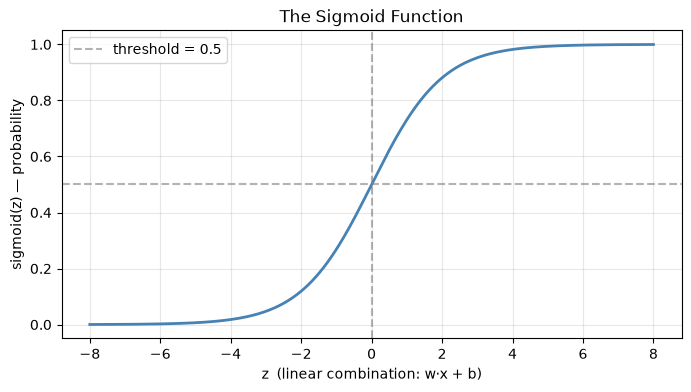

In [38]:
# Visualise the sigmoid
z = np.linspace(-8, 8, 300)
sigmoid_vals = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid_vals, color='steelblue', lw=2)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='threshold = 0.5')
plt.axvline(0, color='gray', linestyle='--', alpha=0.6)
plt.xlabel('z  (linear combination: w·x + b)')
plt.ylabel('sigmoid(z) — probability')
plt.title('The Sigmoid Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Step 4: Log Loss — Scoring Probabilities

MSE was the right loss for predicting numbers. For probabilities the standard choice is **log loss** (also called binary cross-entropy):

$$\text{Log Loss} = -\frac{1}{n} \sum_{i=1}^{n} \left[ \, y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \, \right]$$

where $y_i$ is the true label (0 or 1) and $\hat{y}_i$ is the predicted probability.

The formula looks busy, but for any single sample only one of the two terms survives:

- If the true label is 1, the loss is $-\log(\hat{y})$: predicting 0.99 costs almost nothing, predicting 0.01 costs a fortune.
- If the true label is 0, the loss is $-\log(1 - \hat{y})$: the mirror image.

So log loss punishes the model heavily for being **confidently wrong**, and only mildly for being unsure. It is also mathematically matched to the sigmoid: together they produce the clean gradient you will meet in the code. The plot below shows both curves — watch the loss explode as the predicted probability approaches the wrong end.

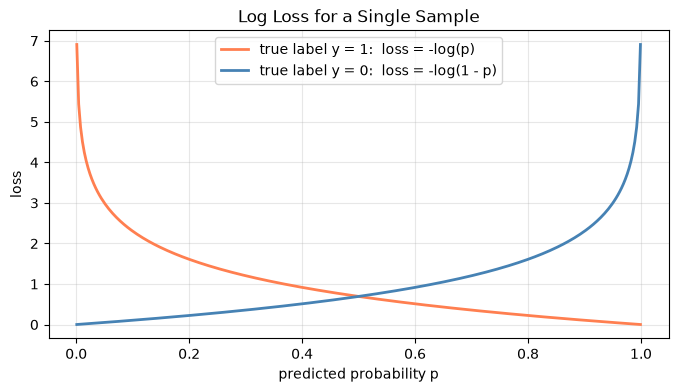

In [40]:
# Visualise log loss for a single sample
p = np.linspace(0.001, 0.999, 300)

plt.figure(figsize=(8, 4))
plt.plot(p, -np.log(p), color='coral', lw=2, label='true label y = 1:  loss = -log(p)')
plt.plot(p, -np.log(1 - p), color='steelblue', lw=2, label='true label y = 0:  loss = -log(1 - p)')
plt.xlabel('predicted probability p')
plt.ylabel('loss')
plt.title('Log Loss for a Single Sample')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Reading the Plot

> **Note:** Read one curve at a time. Suppose the true label is 1 (coral curve): predicting p = 0.9 costs about 0.1, predicting p = 0.1 costs about 2.3, and the loss shoots toward infinity as p approaches 0. The blue curve tells the same story for a true label of 0, mirrored. Being unsure (p near 0.5) costs about 0.69 either way: a moderate, survivable penalty. Keep that 0.69 in mind — you will see it again when training starts.

---
## Step 5: Implement LogisticRegressionGD

Compare this class with the `LinearRegressionGD` class you already built as you fill in the TODOs.
The structure is almost identical — only the three marked parts are new, and none require new ideas: translate the formulas from Steps 3 and 4 into NumPy.

> **Differences you will notice in the side-by-side comparison:** the linear regression class trained a single feature with a scalar `w`; this one is the multi-feature version, so `self.weights` is a vector and the gradient uses the vectorized form `X.T @ (...)` (the `@` operator from the NumPy tutorial). We also track `loss_history` rather than `cost_history`: by the strict loss-vs-cost definitions, the averaged quantity is a cost, but "log loss" is the standard name in practice, and we use it from here on. The class structure itself — init, fit loop, forward pass, gradient, update, predict — is unchanged.

In [49]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.1, n_epochs=1000):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)  # same initialisation as linear regression
        self.bias = 0.0
        self.loss_history = []

        for epoch in range(self.n_epochs):
            # Forward pass — same linear combination as linear regression
            z = X @ self.weights + self.bias
            y_pred = self._sigmoid(z)          # NEW: sigmoid transforms z to probability
            y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)  # avoid log(0)

            loss = -(1 / n_samples) * np.sum( y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

            self.loss_history.append(loss)

            # Gradients — same form as linear regression; sigmoid absorbed into the math
            dw = (1 / n_samples) * (X.T @ (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update — identical to linear regression
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        # TODO 3: return the predicted probabilities (same forward pass as in fit)
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

<details><summary><b>Click for Full Solution</b></summary>

```python
def _sigmoid(self, z):
    return 1 / (1 + np.exp(-z))

# In fit():
loss = -(1 / n_samples) * np.sum(
    y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)
)

def predict_proba(self, X):
    z = X @ self.weights + self.bias
    return self._sigmoid(z)
```

</details>

---
## Step 6: Train the Model

In [50]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

model = LogisticRegressionGD(learning_rate=0.1, n_epochs=1000)
model.fit(X_train, y_train)

print(f'Initial log loss: {model.loss_history[0]:.4f}')
print(f'Final log loss:   {model.loss_history[-1]:.4f}')
print(f'Learned weights:  {model.weights.round(3)}')
print(f'Learned bias:     {model.bias:.3f}')

Initial log loss: 0.6931
Final log loss:   0.1849
Learned weights:  [0.65  3.595]
Learned bias:     -0.348


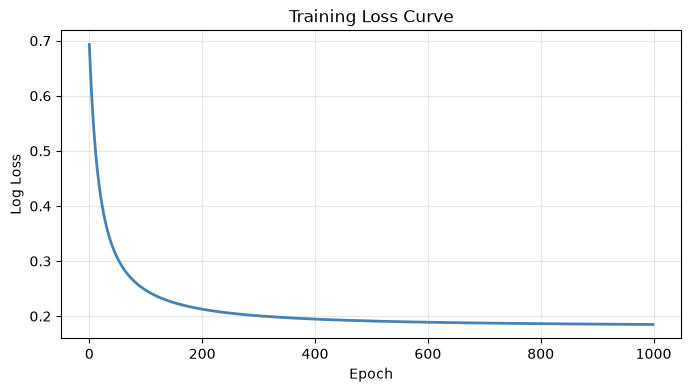

Expected starting loss (all predictions = 0.5): 0.6931


In [51]:
# Loss curve — should decrease and flatten as the model converges
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='steelblue', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.show()

# The loss starts near log(2) ≈ 0.693 because all initial predictions are 0.5
print(f'Expected starting loss (all predictions = 0.5): {-np.log(0.5):.4f}')

### Reading the Loss Curve

> **Note:** The loss starts near 0.693. This is `-log(0.5)`, the loss when every prediction is 0.5 (which is what weights = 0 gives us). As training progresses, the model learns to push probabilities toward 0 or 1, reducing the loss.

---
## Step 7: Visualise the Decision Boundary

The decision boundary is the line where the predicted probability equals 0.5 — the dividing line between class 0 and class 1. Because logistic regression is a **linear classifier** (it applies a linear combination before the sigmoid) and we use the two original features with no non-linear transformations (like polynomial terms), the boundary it draws here is a straight line in 2D.

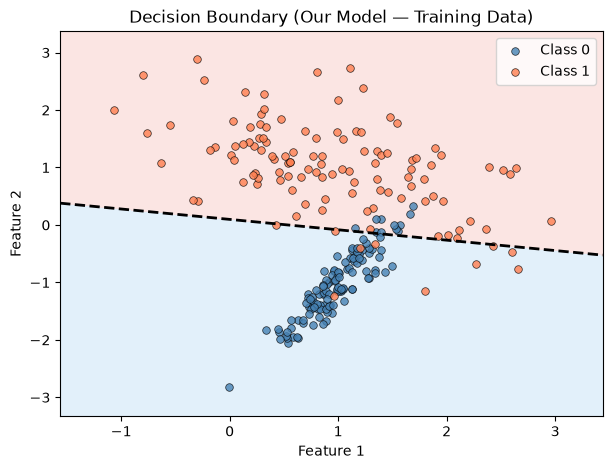

In [46]:
def plot_decision_boundary(model, X, y, title='Decision Boundary'):
    h = 0.05  # grid resolution
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))

    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1],
                 colors=['#d6eaf8', '#fadbd8'], alpha=0.7)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black',
                linewidths=2, linestyles='--')
    for label, color, name in [(0, 'steelblue', 'Class 0'), (1, 'coral', 'Class 1')]:
        mask = y == label
        plt.scatter(X[mask, 0], X[mask, 1], c=color, s=30,
                    edgecolors='black', linewidths=0.5, alpha=0.8, label=name)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(model, X_train, y_train,
                       'Decision Boundary (Our Model — Training Data)')

### Reading the Plot

- **Black dashed line**: where the model's predicted probability = 0.5. Points below the line are predicted Class 0; points above it are predicted Class 1.
- **Blue region**: Class 0 territory (probability < 0.5).
- **Pink region**: Class 1 territory (probability ≥ 0.5).
- The boundary is a straight line because logistic regression is a *linear* classifier — linear in the features you give it. Engineer non-linear features (e.g., polynomial terms) and the boundary can curve in the original feature space; more powerful models (neural networks, decision trees) draw curved boundaries on their own.

---
## Step 8: Compare with sklearn

sklearn's `LogisticRegression` uses a more efficient solver (L-BFGS) and includes **L2 regularization** by default (`C=1.0`). Regularization is a technique for fighting overfitting (we will explore it later in the course). For now, one fact is enough: sklearn applies it by default, and using a very large `C` effectively disables it, which makes the comparison with our plain implementation fair.

In [53]:
# sklearn comparison
sk_model = LogisticRegression(C=1e6, max_iter=1000, random_state=RANDOM_SEED)
sk_model.fit(X_train, y_train)

our_acc = accuracy_score(y_test, model.predict(X_test))
sk_acc  = accuracy_score(y_test, sk_model.predict(X_test))

print(f'Our model test accuracy: {our_acc:.4f}')
print(f'sklearn test accuracy:   {sk_acc:.4f}')
print()
print(f'Our weights:    {model.weights.round(4)}')
print(f'sklearn weights:{sk_model.coef_[0].round(4)}')
print(f'Our bias:    {model.bias:.4f}')
print(f'sklearn bias:{sk_model.intercept_[0]:.4f}')

Our model test accuracy: 0.9500
sklearn test accuracy:   0.9500

Our weights:    [0.6502 3.5954]
sklearn weights:[1.1451 4.0982]
Our bias:    -0.3480
sklearn bias:-0.9675


> **Note:** The test accuracies should match closely, but the raw weights can differ noticeably — plain gradient descent with 1,000 epochs stops before full convergence, while sklearn's solver converges precisely. The loss surface is quite flat near the optimum, so fairly different weights can draw nearly the same decision boundary. If your accuracy is within about 2% of sklearn's here, your implementation is correct.

---
## What You Should Be Able to Do Now

- Explain why plain linear regression is a poor fit for a 0/1 target
- Explain what the sigmoid function does and why it is needed for classification
- Describe what log loss is and why confident wrong predictions incur large loss
- Identify what is identical between `LinearRegressionGD` and `LogisticRegressionGD`, and what the differences are
- Interpret a decision boundary plot, understand why logistic regression draws a linear decision boundary